# E5 — Customer Segment Profiling

## US-5.1 — Global KPI Baseline

In [1]:
from src.config import *
import numpy as np
np.random.seed(RANDOM_STATE)
import pandas as pd

df_customers = pd.read_csv(DATA_PROCESSED_PATH + "customers_with_clusters.csv")
print(f"Customers: {len(df_customers):,} | Clusters: {df_customers['cluster_id'].nunique()}")

Customers: 64,469 | Clusters: 10


### Compute Global KPI Baseline

In [2]:
from src.profiling import compute_global_kpis

global_kpis = compute_global_kpis(df_customers)

### Global Baseline Table

In [3]:
from src.profiling import NUMERICAL_KPIS
from IPython.display import display # Fix linter issue

def format_kpi(kpi_name: str, value: float) -> str:
    if kpi_name.endswith('_ratio') or kpi_name == 'discount_rate':
        return f"{value:.2%}"
    return f"{value:.2f}"

# Formatted baseline table
baseline_rows = {kpi: format_kpi(kpi, global_kpis.get(kpi, np.nan)) for kpi in NUMERICAL_KPIS}
baseline_df = pd.DataFrame.from_dict(baseline_rows, orient='index', columns=['Global Mean'])
baseline_df.index.name = 'KPI'
display(baseline_df)

,Global Mean
KPI,
monetary_avg,40.20
frequency,3.00
avg_basket_size_eur,69.54
avg_units_per_basket,2.01
recency_days,111.44
store_ratio,88.28%
estore_ratio,11.71%
click_collect_ratio,0.01%
axe_make_up_ratio,-inf%


In [4]:
# Loyalty Status Distribution
loyalty_df = pd.DataFrame.from_dict(
    global_kpis.get('loyalty_distribution', {}), orient='index', columns=['Proportion']
)
if not loyalty_df.empty:
    loyalty_df['Proportion'] = loyalty_df['Proportion'].map(lambda x: f"{x:.2%}")
    loyalty_df.index.name = 'Loyalty Status'
    display(loyalty_df)

,Proportion
Loyalty Status,
BRONZE,66.41%
SILVER,29.62%
GOLD,3.97%


In [5]:
# Total customers & total sales
print(f"Total Customers: {global_kpis['total_customers']:,}")
print(f"Total Sales (EUR): {global_kpis['total_sales_eur']:,.2f}")

Total Customers: 64,469
Total Sales (EUR): 12,773,158.16


In [6]:
## US-5.2 — Per-Cluster KPI Computation

In [7]:
from src.profiling import compute_cluster_kpis

cluster_kpis_df = compute_cluster_kpis(df_customers)
display(cluster_kpis_df)

,n_customers,pct_customers,monetary_avg,frequency,avg_basket_size_eur,avg_units_per_basket,recency_days,store_ratio,estore_ratio,click_collect_ratio,axe_make_up_ratio,axe_skincare_ratio,axe_fragrance_ratio,axe_haircare_ratio,axe_others_ratio,discount_rate,monetary_total
cluster_id,,,,,,,,,,,,,,,,,
0,8023,12.444741,30.215004,9.652374,73.256563,2.427986,30.919232,0.885870,0.114112,0.000018,0.442569,0.216872,0.259147,0.054826,0.026586,0.131203,663.017756
1,14813,22.976935,64.413112,2.117802,100.076990,1.764720,113.088436,0.968276,0.031656,0.000068,0.167519,0.095156,0.725087,0.007926,0.004312,0.206693,188.658656
2,2500,3.877833,45.465628,2.446800,60.183084,1.587683,83.009200,0.956694,0.043306,0.000000,0.137579,0.078648,0.078690,0.008929,0.696154,0.004994,137.289732
3,5572,8.642914,48.527266,2.147882,80.672078,2.075933,117.031587,0.057739,0.941992,0.000269,-inf,0.213894,0.377497,0.056017,0.003677,0.204433,168.433225
4,18275,28.346957,25.476034,2.106265,51.985954,2.160857,126.476224,0.967510,0.032545,0.000000,0.534044,0.335025,-inf,0.058097,inf,0.045470,99.233562
5,514,0.797282,38.975539,3.149805,71.355341,2.157056,111.031128,0.987345,0.012655,0.000000,0.433542,0.223454,0.247054,0.051512,0.044437,0.091806,230.484533
6,5986,9.285083,67.186524,1.848146,100.633312,1.746260,126.811727,0.977638,0.022194,0.000167,-inf,0.158380,0.659306,0.021262,inf,0.163979,171.996973
7,112,0.173727,40.616408,4.535714,117.390182,3.263113,93.294643,0.980929,0.019071,0.000000,0.412382,0.220025,0.264292,0.060245,0.043056,0.088265,516.813839
8,6,0.009307,59.040000,1.333333,188.113333,2.833333,33.666667,1.000000,0.000000,0.000000,0.326634,0.042400,0.540150,0.090815,0.000000,0.223633,263.138333


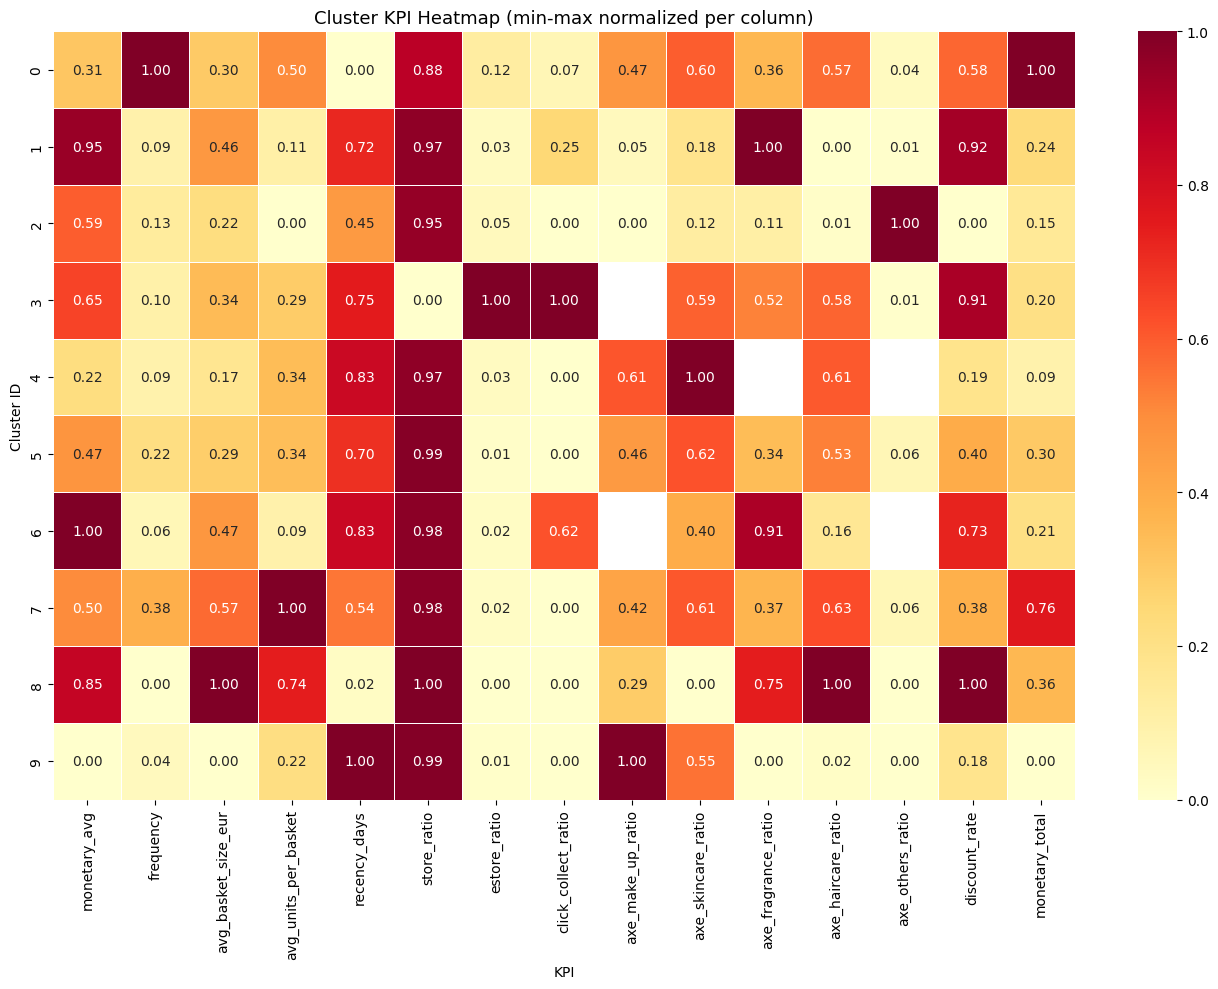

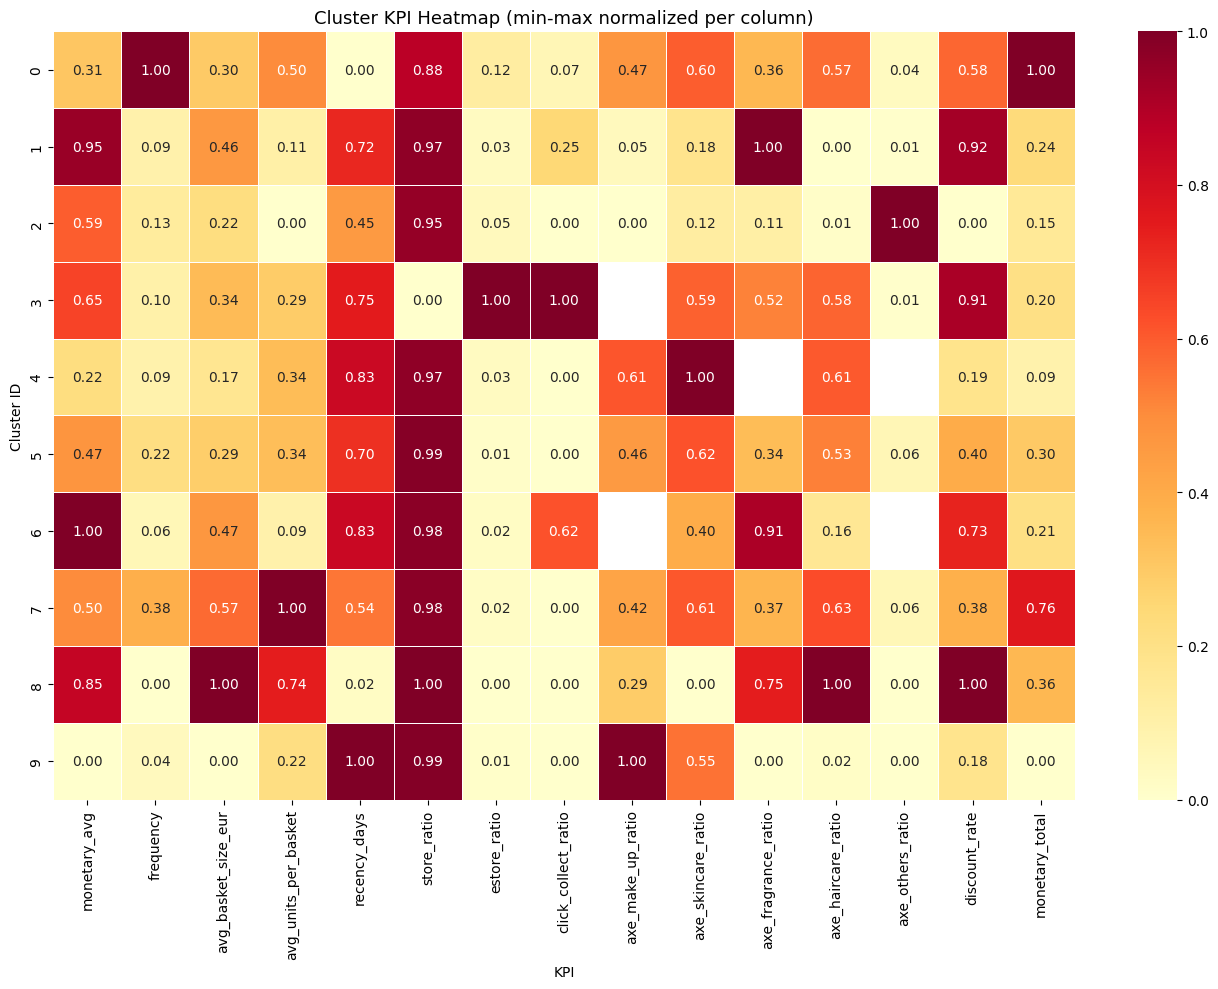

In [8]:
from src.visualization import plot_cluster_kpi_heatmap

fig = plot_cluster_kpi_heatmap(cluster_kpis_df, save_path="figures/cluster_kpi_heatmap.png")
fig

## US-5.3 — Delta Table (Clusters vs. Global Average)

In [9]:
import importlib, src.profiling
importlib.reload(src.profiling)

from src.profiling import build_delta_table, get_notable_deltas, export_delta_table_md
from src.config import OUTPUT_PATH

delta_df = build_delta_table(cluster_kpis_df, global_kpis)
display(delta_df)

/Users/milanviallet/Documents - MacBook Air de Milan/Albert/B2/BDD/Sephora/src/profiling.py:54: RuntimeWarning: invalid value encountered in scalar subtract
  delta_abs = cluster_val - global_val
/Users/milanviallet/Documents - MacBook Air de Milan/Albert/B2/BDD/Sephora/src/profiling.py:55: RuntimeWarning: invalid value encountered in scalar divide
  delta_pct = ((cluster_val / global_val) - 1) * 100 if global_val != 0 else np.nan


,cluster_id,kpi,global_avg,cluster_value,delta_abs,delta_pct
0,0,avg_basket_size_eur,69.5360,73.2566,3.7206,5.35
1,0,avg_units_per_basket,2.0088,2.4280,0.4192,20.87
2,0,axe_fragrance_ratio,-inf,0.2591,inf,-100.00
3,0,axe_haircare_ratio,0.0341,0.0548,0.0208,60.93
4,0,axe_make_up_ratio,-inf,0.4426,inf,-100.00
...,...,...,...,...,...,...
145,9,frequency,2.9960,1.6799,-1.3161,-43.93
146,9,monetary_avg,40.2007,13.6579,-26.5429,-66.03
147,9,monetary_total,198.1287,41.1206,-157.0081,-79.25
148,9,recency_days,111.4422,145.7695,34.3273,30.80


### Color-Coded Delta Table

In [10]:
# Pivot to wide format for display: rows = clusters, columns = KPIs, values = delta_pct
delta_wide = delta_df.pivot(index='cluster_id', columns='kpi', values='delta_pct')

# Color-coded display: green = above average, red = below average
styled = delta_wide.style.background_gradient(
    cmap='RdYlGn', axis=None, vmin=-100, vmax=100
).format("{:.1f}%").set_caption("Delta % vs. Global Average (green = above, red = below)")
styled

kpi,avg_basket_size_eur,avg_units_per_basket,axe_fragrance_ratio,axe_haircare_ratio,axe_make_up_ratio,axe_others_ratio,axe_skincare_ratio,click_collect_ratio,discount_rate,estore_ratio,frequency,monetary_avg,monetary_total,recency_days,store_ratio
cluster_id,,,,,,,,,,,,,,,
0,5.3%,20.9%,-100.0%,60.9%,-100.0%,-100.0%,3.5%,-68.5%,12.4%,-2.6%,222.2%,-24.8%,234.6%,-72.3%,0.3%
7,68.8%,62.4%,-100.0%,76.8%,-100.0%,-100.0%,5.0%,-100.0%,-24.4%,-83.7%,51.4%,1.0%,160.8%,-16.3%,11.1%
8,170.5%,41.0%,-100.0%,166.6%,-100.0%,-100.0%,-79.8%,-100.0%,91.7%,-100.0%,-55.5%,46.9%,32.8%,-69.8%,13.3%
5,2.6%,7.4%,-100.0%,51.2%,-100.0%,-100.0%,6.6%,-100.0%,-21.3%,-89.2%,5.1%,-3.0%,16.3%,-0.4%,11.8%
1,43.9%,-12.2%,-100.0%,-76.7%,-100.0%,-100.0%,-54.6%,19.5%,77.2%,-73.0%,-29.3%,60.2%,-4.8%,1.5%,9.7%
6,44.7%,-13.1%,-100.0%,-37.6%,nan%,nan%,-24.4%,195.7%,40.5%,-81.0%,-38.3%,67.1%,-13.2%,13.8%,10.7%
3,16.0%,3.3%,-100.0%,64.4%,nan%,-100.0%,2.0%,376.4%,75.2%,704.1%,-28.3%,20.7%,-15.0%,5.0%,-93.5%
2,-13.4%,-21.0%,-100.0%,-73.8%,-100.0%,-100.0%,-62.5%,-100.0%,-95.7%,-63.0%,-18.3%,13.1%,-30.7%,-25.5%,8.4%
4,-25.2%,7.6%,nan%,70.5%,-100.0%,nan%,59.8%,-100.0%,-61.0%,-72.2%,-29.7%,-36.6%,-49.9%,13.5%,9.6%


### Notable Deltas (|Δ%| > 30%)

In [11]:
notable = get_notable_deltas(delta_df)

if notable.empty:
    print("No notable deltas (|Δ%| > 30%) found.")
else:
    print(f"{len(notable)} notable deviations found:\n")
    for _, r in notable.iterrows():
        direction = "above" if r['delta_pct'] > 0 else "below"
        print(f"  Cluster {r['cluster_id']} — {r['kpi']}: {r['delta_pct']:+.1f}% {direction} global avg")

91 notable deviations found:

  Cluster 0 — axe_fragrance_ratio: -100.0% below global avg
  Cluster 0 — axe_haircare_ratio: +60.9% above global avg
  Cluster 0 — axe_make_up_ratio: -100.0% below global avg
  Cluster 0 — axe_others_ratio: -100.0% below global avg
  Cluster 0 — click_collect_ratio: -68.5% below global avg
  Cluster 0 — frequency: +222.2% above global avg
  Cluster 0 — monetary_total: +234.6% above global avg
  Cluster 0 — recency_days: -72.3% below global avg
  Cluster 7 — avg_basket_size_eur: +68.8% above global avg
  Cluster 7 — avg_units_per_basket: +62.4% above global avg
  Cluster 7 — axe_fragrance_ratio: -100.0% below global avg
  Cluster 7 — axe_haircare_ratio: +76.8% above global avg
  Cluster 7 — axe_make_up_ratio: -100.0% below global avg
  Cluster 7 — axe_others_ratio: -100.0% below global avg
  Cluster 7 — click_collect_ratio: -100.0% below global avg
  Cluster 7 — estore_ratio: -83.7% below global avg
  Cluster 7 — frequency: +51.4% above global avg
  Cluste

### Export Delta Table

In [12]:
export_path = OUTPUT_PATH + "kpi_delta_table.md"
export_delta_table_md(delta_df, export_path)
print(f"Delta table exported to {export_path}")

Delta table exported to _bmad-output/implementation-artifacts/kpi_delta_table.md


In [13]:
import importlib, src.visualization
importlib.reload(src.visualization)
print("visualization module reloaded")

visualization module reloaded


## US 5.4 — Top Distinguishing Features per Cluster (Cohen's d)

In [ ]:
from src.profiling import compute_distinguishing_features
from src.visualization import plot_distinguishing_features

# Compute Cohen's d per cluster
features = [k for k in NUMERICAL_KPIS if k in df_customers.columns]
distinguishing_features = compute_distinguishing_features(df_customers, features)

# Display top 5 features per cluster
for cluster_id in sorted(distinguishing_features.keys()):
    top5 = distinguishing_features[cluster_id].head(5)
    print(f"\n--- Cluster {cluster_id} — Top 5 Distinguishing Features ---")
    print(top5[['feature', 'cohens_d']].to_string(index=False))

In [ ]:
# Bar charts — top distinguishing features per cluster
figs = plot_distinguishing_features(distinguishing_features, top_n=5, save_dir="figures")
print(f"{len(figs)} figures saved to figures/")